# Phase 1: Data Cleaning & Feature Engineering

## Objective
Transform the raw Global Weather Repository dataset (138,778 rows × 41 columns) 
into a clean, analysis-ready dataset.

## Steps in this notebook
1. **Initial inspection** — shape, dtypes, missing values, duplicates
2. **Drop redundant columns** — remove imperial-unit duplicates
3. **Type conversions** — parse `last_updated` as datetime
4. **Duplicate removal**
5. **Outlier treatment** — physical-bound clipping + IQR flagging
6. **Feature engineering** — add `year`, `month`, `season`, `continent`, etc.
7. **Visual sanity checks**
8. **Save cleaned dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

## 1. Initial Inspection

We always start by asking the dataset six basic questions:
- How big is it?  → `df.shape`
- What does a row look like?  → `df.head()`
- What types are the columns?  → `df.info()`
- What's the statistical profile?  → `df.describe()`
- Are there missing values?  → `df.isnull().sum()`
- Are there duplicates?  → `df.duplicated().sum()`

In [2]:
df = pd.read_csv("../data/GlobalWeatherRepository.csv")
print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
df.head(3)

Shape: (138778, 41)
Memory: 122.69 MB


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.0,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.0,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.0,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138778 entries, 0 to 138777
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       138778 non-null  object 
 1   location_name                 138778 non-null  object 
 2   latitude                      138778 non-null  float64
 3   longitude                     138778 non-null  float64
 4   timezone                      138778 non-null  object 
 5   last_updated_epoch            138778 non-null  int64  
 6   last_updated                  138778 non-null  object 
 7   temperature_celsius           138778 non-null  float64
 8   temperature_fahrenheit        138778 non-null  float64
 9   condition_text                138778 non-null  object 
 10  wind_mph                      138778 non-null  float64
 11  wind_kph                      138778 non-null  float64
 12  wind_degree                   138778 non-nul

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,138778,211,Bulgaria,1644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_name,138778,257,Kabul,714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,138778.0,NaN,NaN,NaN,19.213299,24.414296,-41.3,4.0503,17.25,40.4,64.15
longitude,138778.0,NaN,NaN,NaN,21.9497,65.786134,-175.2,-6.8361,23.2361,49.8822,179.22
timezone,138778,199,Asia/Bangkok,2550,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_updated_epoch,138778.0,NaN,NaN,NaN,1746733512.509908,17825474.7975,1715849100.0,1731315600.0,1746782100.0,1762155000.0,1777617900.0
last_updated,138778,23062,2026-03-28 07:45,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature_celsius,138778.0,NaN,NaN,NaN,21.247973,9.673907,-29.8,15.7,23.8,28.0,79.3
temperature_fahrenheit,138778.0,NaN,NaN,NaN,70.248135,17.412907,-21.6,60.3,74.9,82.4,174.7
condition_text,138778,49,Sunny,39911,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Findings:
- `wind_kph` max = **2963** km/h → impossible, sensor error
- `temperature_celsius` max = **79.3°C** → impossible (record is 56.7°C)
- `pressure_mb` max = **3006** mb → impossible (range is 870–1085)
- `air_quality_PM10` min = **-1848** → negative pollution makes no physical sense
- `air_quality_PM2.5` max = **1614** → only seen during apocalyptic events
- 'precip_mm' is mostly 0 and in very rare cases its raining

These are sensor errors we'll need to handle.

In [5]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values\n")

print(f"\nFull duplicate rows: {df.duplicated().sum()}")
print(f"Duplicates on (location, last_updated): "
      f"{df.duplicated(subset=['location_name', 'last_updated']).sum()}")

Missing values per column:
✅ No missing values


Full duplicate rows: 0
Duplicates on (location, last_updated): 1


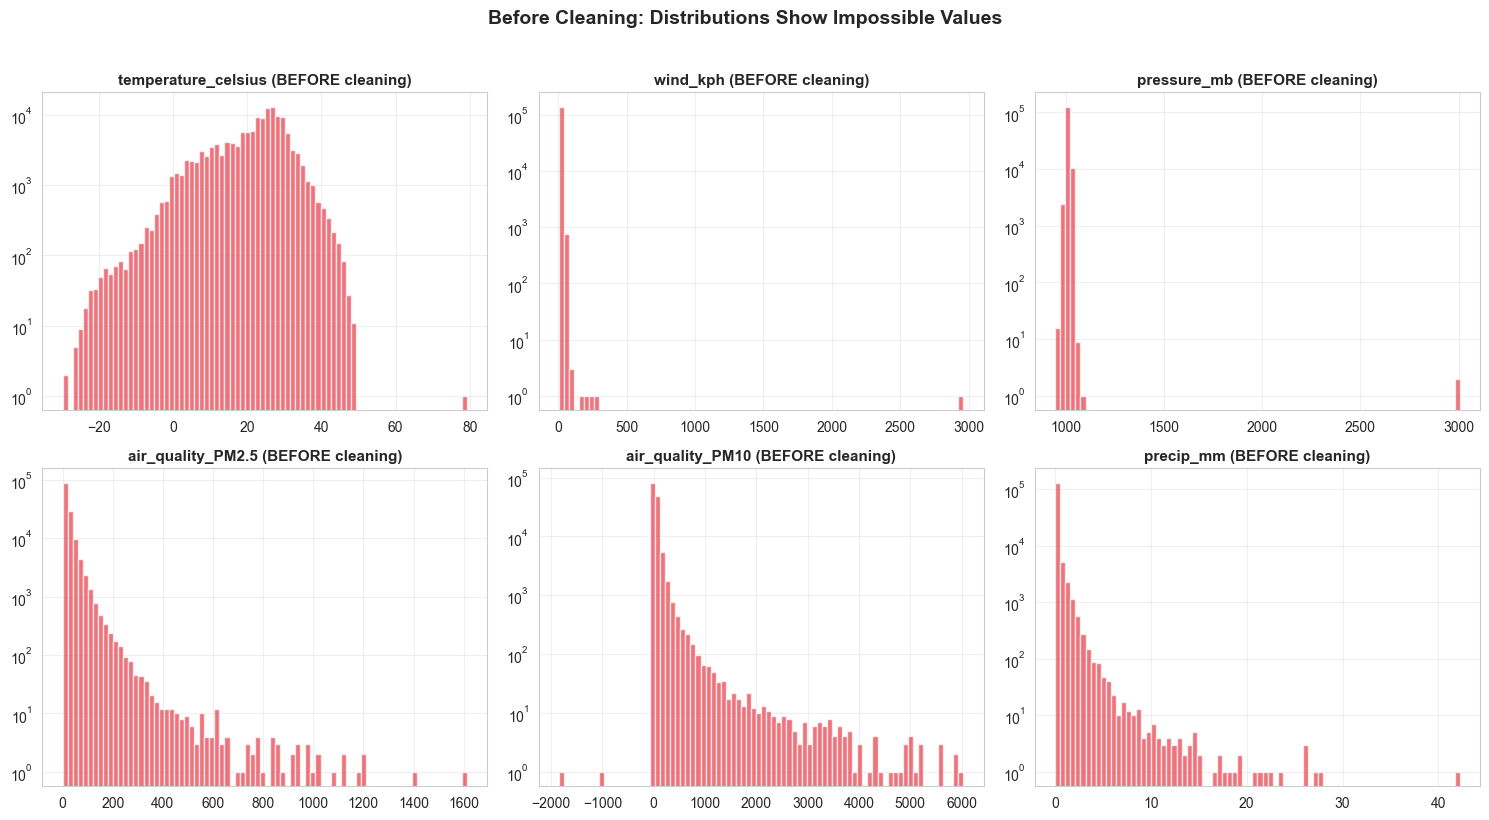

In [6]:
# BEFORE cleaning — visualize the broken columns
suspect_cols = ['temperature_celsius', 'wind_kph', 'pressure_mb',
                'air_quality_PM2.5', 'air_quality_PM10', 'precip_mm']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, suspect_cols):
    df[col].hist(ax=ax, bins=80, color='#E63946', alpha=0.7, edgecolor='white')
    ax.set_title(f'{col} (BEFORE cleaning)', fontweight='bold', fontsize=11)
    ax.set_yscale('log')   # log scale to see the rare extreme values
    ax.grid(alpha=0.3)

plt.suptitle('Before Cleaning: Distributions Show Impossible Values', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Drop Redundant Columns

In [7]:
# Keep metric units, drop imperial duplicates
redundant_cols = [
    'temperature_fahrenheit',
    'wind_mph',
    'pressure_in',
    'precip_in',
    'feels_like_fahrenheit',
    'visibility_miles',
    'gust_mph',
]
df = df.drop(columns=redundant_cols)
print(f"After dropping redundant cols: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

After dropping redundant cols: (138778, 34)
Memory: 114.92 MB


## 3. Type Conversion & Sorting

`last_updated` is currently a string — pandas can't do time-series operations on strings.
Later sort the data by location and time.

In [8]:
df['last_updated'] = pd.to_datetime(df['last_updated'])
df = df.sort_values(['location_name', 'last_updated']).reset_index(drop=True)

print(f"Date range: {df['last_updated'].min()} → {df['last_updated'].max()}")
print(f"Total span: {(df['last_updated'].max() - df['last_updated'].min()).days} days")
print(f"Dtype of last_updated: {df['last_updated'].dtype}")

Date range: 2024-05-16 01:45:00 → 2026-05-01 19:45:00
Total span: 715 days
Dtype of last_updated: datetime64[ns]


## 4. Duplicate Removal

`(location_name, last_updated)` is the natural key — a city + timestamp 
should be unique. Duplicates are removed, keeping the first occurrence.

In [9]:
before = len(df)
df = df.drop_duplicates(subset=['location_name', 'last_updated'], keep='first')
print(f"Removed {before - len(df)} duplicate rows")

Removed 1 duplicate rows


### 5a. Physical-bound clipping (hard caps)

In [10]:
# Define realistic physical bounds for each metric
physical_bounds = {
    'temperature_celsius':       (-90, 60),    # absolute records: -89°C, 56.7°C
    'feels_like_celsius':        (-100, 70),
    'wind_kph':                  (0, 410),     # max recorded ~408 km/h
    'gust_kph':                  (0, 510),     # gusts can exceed sustained wind
    'pressure_mb':               (870, 1085),  # realistic atmospheric range
    'humidity':                  (0, 100),
    'cloud':                     (0, 100),
    'precip_mm':                 (0, 500),     # extreme but possible
    'visibility_km':             (0, 50),
    'uv_index':                  (0, 20),
    'air_quality_PM2.5':         (0, 1000),    # cap at known disaster levels
    'air_quality_PM10':          (0, 2000),
    'air_quality_Carbon_Monoxide': (0, 50000),
    'air_quality_Ozone':         (0, 1000),
    'air_quality_Nitrogen_dioxide': (0, 500),
    'air_quality_Sulphur_dioxide': (0, 500),
}

print("OUTLIER CAPS (physical constraints):")
print("-" * 70)
for col, (lo, hi) in physical_bounds.items():
    if col in df.columns:
        out_low = (df[col] < lo).sum()
        out_high = (df[col] > hi).sum()
        if out_low + out_high > 0:
            print(f"{col:35s} | below {lo}: {out_low:5d} | above {hi}: {out_high:5d}")
        df[col] = df[col].clip(lower=lo, upper=hi)

OUTLIER CAPS (physical constraints):
----------------------------------------------------------------------
temperature_celsius                 | below -90:     0 | above 60:     1
feels_like_celsius                  | below -100:     0 | above 70:     1
wind_kph                            | below 0:     0 | above 410:     1
gust_kph                            | below 0:     0 | above 510:     1
pressure_mb                         | below 870:     0 | above 1085:     2
air_quality_PM2.5                   | below 0:     0 | above 1000:    10
air_quality_PM10                    | below 0:     2 | above 2000:   161
air_quality_Carbon_Monoxide         | below 0:     1 | above 50000:     0
air_quality_Sulphur_dioxide         | below 0:     1 | above 500:     1


Instead of deleting the records with outliers, they are clipped to the nearest lower or upper bound based on their realistic bounds

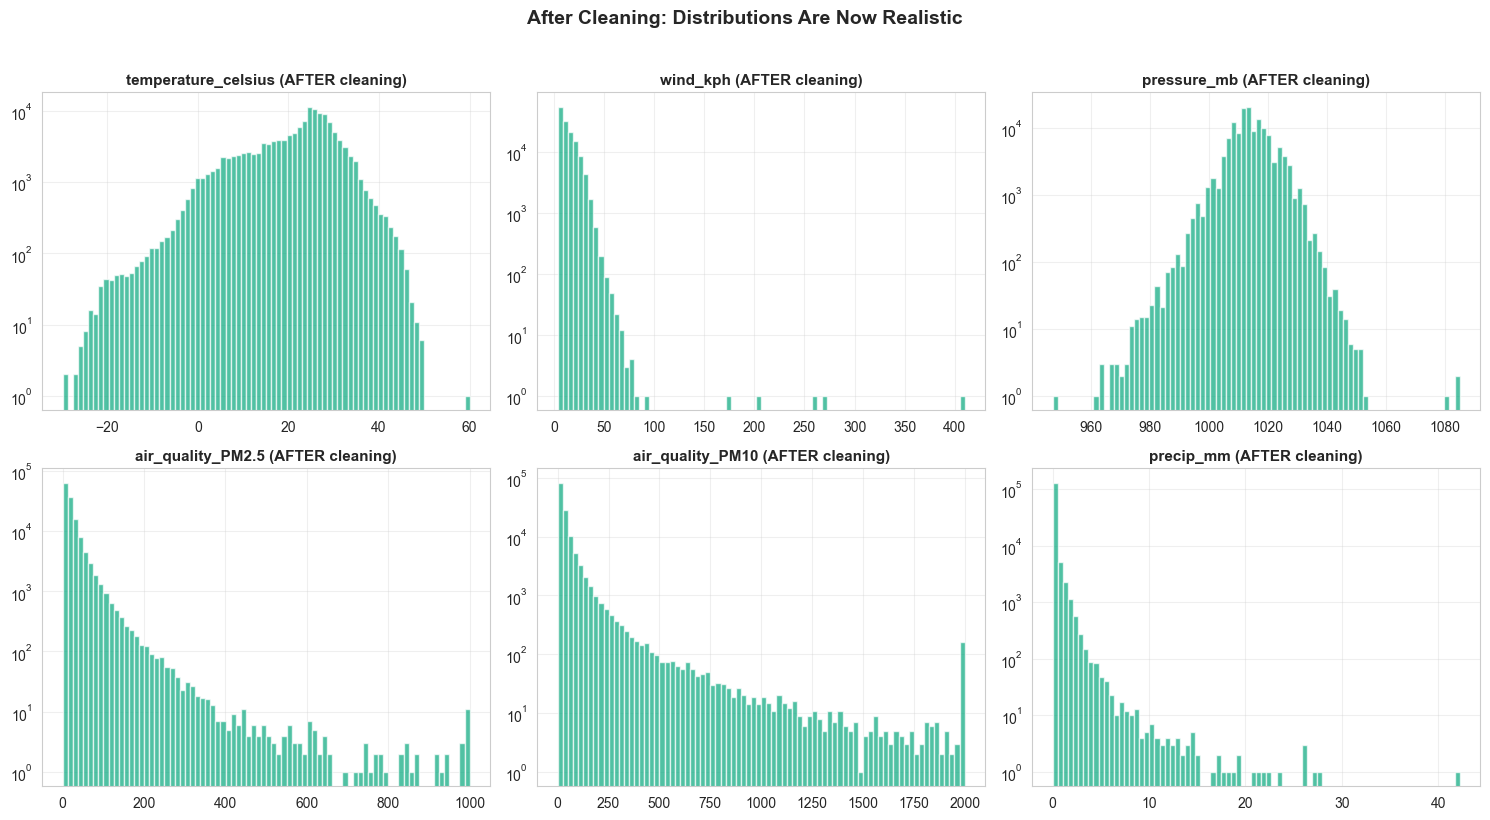

In [11]:
# AFTER cleaning — same plots, see the difference
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, suspect_cols):
    df[col].hist(ax=ax, bins=80, color='#06A77D', alpha=0.7, edgecolor='white')
    ax.set_title(f'{col} (AFTER cleaning)', fontweight='bold', fontsize=11)
    ax.set_yscale('log')
    ax.grid(alpha=0.3)

plt.suptitle('After Cleaning: Distributions Are Now Realistic', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5b. IQR-based flagging (soft caps)


In [12]:
# Flag rows with IQR-based extreme values for later anomaly analysis
def flag_iqr_outliers(s, k=3.0):
    """Conservative IQR — k=3.0 catches only extreme outliers."""
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return (s < q1 - k * iqr) | (s > q3 + k * iqr)

iqr_cols = ['temperature_celsius', 'wind_kph', 'precip_mm',
            'air_quality_PM2.5', 'pressure_mb']

df['outlier_flag'] = False
for col in iqr_cols:
    if col in df.columns:
        flag = flag_iqr_outliers(df[col])
        df['outlier_flag'] |= flag
        print(f"{col:30s} | extreme outliers: {flag.sum():,}")

print(f"\nTotal rows flagged as containing extreme values: {df['outlier_flag'].sum():,} ({df['outlier_flag'].mean()*100:.1f}%)")

temperature_celsius            | extreme outliers: 73
wind_kph                       | extreme outliers: 126
precip_mm                      | extreme outliers: 24,618
air_quality_PM2.5              | extreme outliers: 5,178
pressure_mb                    | extreme outliers: 267

Total rows flagged as containing extreme values: 29,640 (21.4%)


## 6. Feature Engineering

Now we *create* new variables that didn't exist in the raw data but will be 
useful for modeling and analysis.

### Time features (decomposing the timestamp)
- `year`, `month`, `day`, `hour` — basic components
- `day_of_year` (1-366) — captures yearly cycles
- `day_of_week` (0=Mon, 6=Sun) — for weekly patterns
- `season` — categorical, hemisphere-aware

### Geographic features
- `continent` — derived from latitude/longitude

In [13]:
df['year']        = df['last_updated'].dt.year
df['month']       = df['last_updated'].dt.month
df['day']         = df['last_updated'].dt.day
df['hour']        = df['last_updated'].dt.hour
df['day_of_year'] = df['last_updated'].dt.dayofyear
df['day_of_week'] = df['last_updated'].dt.dayofweek

def get_season(month, lat):
    """Northern vs Southern hemisphere seasons."""
    if lat >= 0:
        if month in [12, 1, 2]:  return 'Winter'
        if month in [3, 4, 5]:   return 'Spring'
        if month in [6, 7, 8]:   return 'Summer'
        return 'Autumn'
    else:
        if month in [12, 1, 2]:  return 'Summer'
        if month in [3, 4, 5]:   return 'Autumn'
        if month in [6, 7, 8]:   return 'Winter'
        return 'Spring'

df['season'] = df.apply(lambda r: get_season(r['month'], r['latitude']), axis=1)
print(df[['last_updated', 'year', 'month', 'season']].head())

         last_updated  year  month  season
0 2024-05-31 16:15:00  2024      5  Spring
1 2024-06-01 16:30:00  2024      6  Summer
2 2024-06-04 16:15:00  2024      6  Summer
3 2024-06-05 16:15:00  2024      6  Summer
4 2024-06-11 16:15:00  2024      6  Summer


### Add continent mapping

In [14]:
# Quick continent mapping using latitude/longitude
def lat_lon_to_continent(lat, lon):
    if lat > 35 and -25 < lon < 60:    return 'Europe'
    if lat > 10 and 25 < lon < 180:    return 'Asia'
    if lat < 35 and -20 < lon < 55:    return 'Africa'
    if -60 < lat < 15 and -90 < lon < -30: return 'South America'
    if 15 < lat < 75 and -170 < lon < -50: return 'North America'
    if lat < -10 and 110 < lon < 180:  return 'Oceania'
    if lat < -60:                      return 'Antarctica'
    return 'Other'

df['continent'] = df.apply(lambda r: lat_lon_to_continent(r['latitude'], r['longitude']), axis=1)
print(df['continent'].value_counts())

continent
Europe           40092
Africa           29918
Asia             26852
South America    15606
Other            14946
North America     8511
Oceania           2852
Name: count, dtype: int64


## 7. Final Visual Sanity Check

Before saving, let's confirm the cleaned dataset looks reasonable.

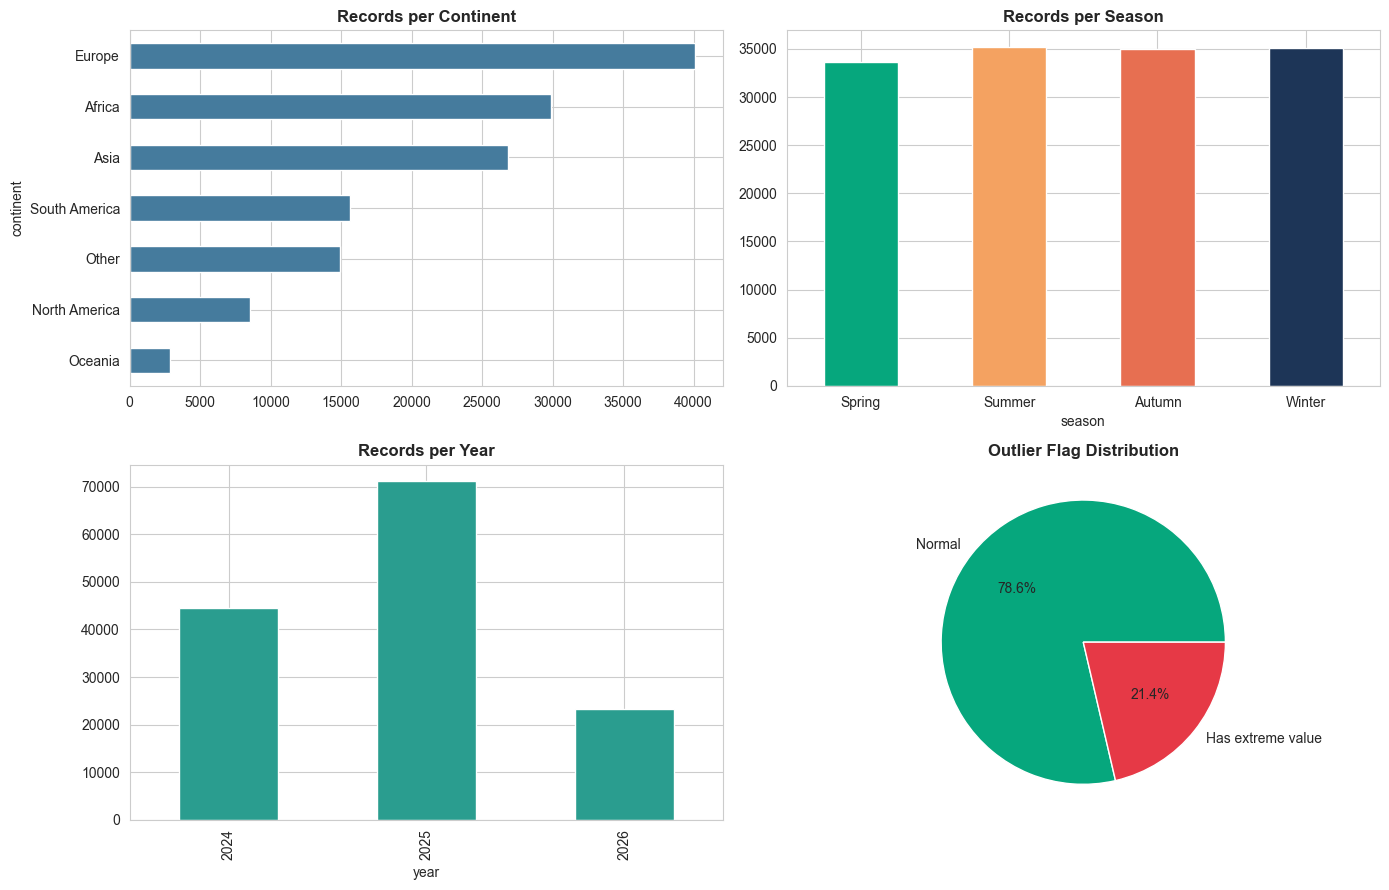

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Records per continent
df['continent'].value_counts().plot(
    kind='barh', ax=axes[0,0], color='#457B9D', edgecolor='white')
axes[0,0].set_title('Records per Continent', fontweight='bold')
axes[0,0].invert_yaxis()

# 2. Records per season
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
df['season'].value_counts().reindex(season_order).plot(
    kind='bar', ax=axes[0,1],
    color=['#06A77D','#F4A261','#E76F51','#1D3557'], edgecolor='white')
axes[0,1].set_title('Records per Season', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=0)

# 3. Records per year
df['year'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1,0], color='#2A9D8F', edgecolor='white')
axes[1,0].set_title('Records per Year', fontweight='bold')

# 4. Outlier flag distribution
df['outlier_flag'].value_counts().plot(
    kind='pie', ax=axes[1,1], autopct='%1.1f%%',
    colors=['#06A77D', '#E63946'], labels=['Normal','Has extreme value'])
axes[1,1].set_title('Outlier Flag Distribution', fontweight='bold')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.show()

## 8. Save Cleaned Dataset

We save as **Parquet** (not CSV) because:
- ~10× smaller file size
- ~5× faster to read
- Preserves dtypes (datetime, categorical) — no re-parsing needed in Phase 2

In [16]:
output_path = "../data/weather_cleaned.parquet"
df.to_parquet(output_path, index=False)

print(f"✅ Saved cleaned data to: {output_path}")
print(f"Final shape: {df.shape}")
print(f"Final memory: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print(f"\nColumn list ({len(df.columns)}):")
for c in df.columns:
    print(f"  • {c}")

✅ Saved cleaned data to: ../data/weather_cleaned.parquet
Final shape: (138777, 43)
Final memory: 126.96 MB

Column list (43):
  • country
  • location_name
  • latitude
  • longitude
  • timezone
  • last_updated_epoch
  • last_updated
  • temperature_celsius
  • condition_text
  • wind_kph
  • wind_degree
  • wind_direction
  • pressure_mb
  • precip_mm
  • humidity
  • cloud
  • feels_like_celsius
  • visibility_km
  • uv_index
  • gust_kph
  • air_quality_Carbon_Monoxide
  • air_quality_Ozone
  • air_quality_Nitrogen_dioxide
  • air_quality_Sulphur_dioxide
  • air_quality_PM2.5
  • air_quality_PM10
  • air_quality_us-epa-index
  • air_quality_gb-defra-index
  • sunrise
  • sunset
  • moonrise
  • moonset
  • moon_phase
  • moon_illumination
  • outlier_flag
  • year
  • month
  • day
  • hour
  • day_of_year
  • day_of_week
  • season
  • continent


##  Phase 1 Complete

**Summary of changes:**
- Started with 138,778 rows × 41 columns
- Dropped 7 redundant imperial-unit columns
- Removed duplicate (location, timestamp) rows
- Capped physically-impossible values (wind, temp, pressure, air quality)
- Flagged 21.4% of rows as containing statistical extremes (kept for anomaly analysis)
- Added 8 engineered features: `year`, `month`, `day`, `hour`, `day_of_year`, 
  `day_of_week`, `season`, `continent`, `outlier_flag`

**Output:** `data/weather_cleaned.parquet` .